In [2]:
# ============================================
# ✅ IMPORTS
# ============================================
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
# ============================================
# ✅ SETTINGS
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

resize = 224
INIT_LR = 1e-4
EPOCHS = 25
FT_EPOCHS = 10
BS = 32

base_dir = "SkinType_Dataset"
TRAIN_DIR = os.path.join(base_dir, "train")
VALID_DIR = os.path.join(base_dir, "valid")
TEST_DIR  = os.path.join(base_dir, "test")

for d in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    assert os.path.exists(d), f"❌ Missing folder: {d}"

categories = sorted(os.listdir(TRAIN_DIR))
print("Classes:", categories)

Using: cuda
Classes: ['Dry', 'Normal', 'Oily']


In [4]:
# ============================================
# ✅ TRANSFORMS
# ============================================
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_tf = transforms.Compose([
    transforms.Resize((resize, resize)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(resize),
    transforms.ToTensor(),
    normalize
])

test_tf = transforms.Compose([
    transforms.Resize((resize, resize)),
    transforms.ToTensor(),
    normalize
])

In [5]:
# ============================================
# ✅ DATA LOADERS
# ============================================
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
valid_ds = datasets.ImageFolder(VALID_DIR, transform=test_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BS, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BS, shuffle=False)

In [6]:
# ============================================
# ✅ CLASS WEIGHTS
# ============================================
labels = [label for _, label in train_ds.samples]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class Weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class Weights: tensor([1., 1., 1.], device='cuda:0')


In [7]:
# ============================================
# ✅ MODEL SETUP — MobileNetV2
# ============================================
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 3)  # 3 classes (Dry, Normal, Oily)
model = model.to(device)

# ✅ Freeze backbone
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=INIT_LR)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\karti/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:03<00:00, 4.26MB/s]


In [8]:
# ============================================
# ✅ TRAINING — STAGE 1 (train classifier only)
# ============================================
print("\n✅ Training Stage 1 (Classifier Only)...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss/len(train_loader):.4f}")


✅ Training Stage 1 (Classifier Only)...
Epoch [1/25] Loss: 1.0963
Epoch [2/25] Loss: 1.0538
Epoch [3/25] Loss: 1.0184
Epoch [4/25] Loss: 0.9752
Epoch [5/25] Loss: 0.9566
Epoch [6/25] Loss: 0.9219
Epoch [7/25] Loss: 0.9070
Epoch [8/25] Loss: 0.8880
Epoch [9/25] Loss: 0.8797
Epoch [10/25] Loss: 0.8558
Epoch [11/25] Loss: 0.8554
Epoch [12/25] Loss: 0.8437
Epoch [13/25] Loss: 0.8259
Epoch [14/25] Loss: 0.8232
Epoch [15/25] Loss: 0.8163
Epoch [16/25] Loss: 0.8291
Epoch [17/25] Loss: 0.8084
Epoch [18/25] Loss: 0.8007
Epoch [19/25] Loss: 0.7926
Epoch [20/25] Loss: 0.8013
Epoch [21/25] Loss: 0.7675
Epoch [22/25] Loss: 0.7887
Epoch [23/25] Loss: 0.7654
Epoch [24/25] Loss: 0.7537
Epoch [25/25] Loss: 0.7449


In [9]:
# ============================================
# ✅ FINE-TUNE — STAGE 2 (train all layers)
# ============================================
print("\n✅ Fine-tuning Entire Model...")
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

best_acc = 0
for epoch in range(FT_EPOCHS):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"FineTune Epoch [{epoch+1}/{FT_EPOCHS}] Loss: {total_loss/len(train_loader):.4f}")

    # ✅ Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            pred = torch.argmax(out, dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Validation Accuracy: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "mobilenetv2_skin_classifier.pth")
        print("✅ Saved best model!")


✅ Fine-tuning Entire Model...
FineTune Epoch [1/10] Loss: 0.7415
Validation Accuracy: 0.6957
✅ Saved best model!
FineTune Epoch [2/10] Loss: 0.7235
Validation Accuracy: 0.7391
✅ Saved best model!
FineTune Epoch [3/10] Loss: 0.6960
Validation Accuracy: 0.7391
FineTune Epoch [4/10] Loss: 0.7151
Validation Accuracy: 0.7391
FineTune Epoch [5/10] Loss: 0.6756
Validation Accuracy: 0.6957
FineTune Epoch [6/10] Loss: 0.6763
Validation Accuracy: 0.6957
FineTune Epoch [7/10] Loss: 0.6578
Validation Accuracy: 0.6522
FineTune Epoch [8/10] Loss: 0.6374
Validation Accuracy: 0.6957
FineTune Epoch [9/10] Loss: 0.6300
Validation Accuracy: 0.7826
✅ Saved best model!
FineTune Epoch [10/10] Loss: 0.5951
Validation Accuracy: 0.7391



✅ Testing Model...
              precision    recall  f1-score   support

         Dry       0.86      0.75      0.80         8
      Normal       0.88      0.70      0.78        10
        Oily       0.62      0.80      0.70        10

    accuracy                           0.75        28
   macro avg       0.78      0.75      0.76        28
weighted avg       0.78      0.75      0.75        28



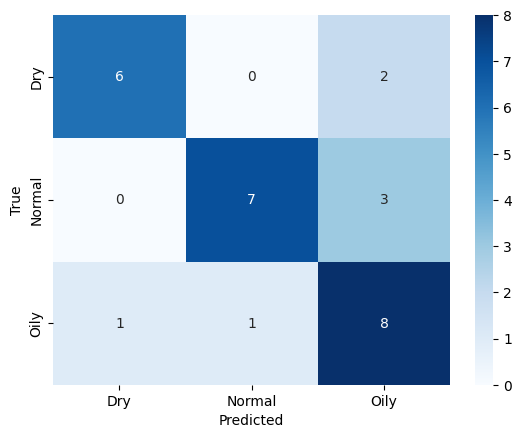

✅ Training complete! Best model saved as mobilenetv2_skin_classifier.pth


In [10]:
# ============================================
# ✅ EVALUATION ON TEST SET
# ============================================
print("\n✅ Testing Model...")
model.eval()
all_preds, all_tgts = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        preds = torch.argmax(out, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_tgts.extend(labels.numpy())

print(classification_report(all_tgts, all_preds, target_names=categories))

cm = confusion_matrix(all_tgts, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("✅ Training complete! Best model saved as mobilenetv2_skin_classifier.pth")

In [11]:
# ============================================
# ✅ INFERENCE
# ============================================
from PIL import Image
import cv2

class_names = ["Dry", "Normal", "Oily"]

# ✅ Load model
model = models.mobilenet_v2()
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 3)
model.load_state_dict(torch.load("mobilenetv2_skin_classifier.pth", map_location='cpu'))
model.eval()

# ✅ same preprocess as training
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    tensor = tf(pil_img).unsqueeze(0)

    with torch.no_grad():
        pred = model(tensor)
        probs = torch.softmax(pred, dim=1)
        idx = torch.argmax(probs).item()
        confidence = probs[0][idx].item() * 100

    print(f"Predicted: {class_names[idx]} ({confidence:.2f}%)")

# ✅ TEST
predict("Inf_Image/4_Oily.jpg")

Predicted: Oily (81.25%)
